In [1]:
!pip install -q xgboost shap joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import joblib
import shap

In [3]:
df = pd.read_csv("/content/ev_charging_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 8354
Columns: 27


In [4]:
timestamp_columns = [
    "timestamp",
    "arrival_time",
    "charging_start_time",
    "charging_end_time"
]

for col in timestamp_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df.dtypes)

timestamp                 datetime64[ns]
station_id                        object
location_type                     object
vehicle_id                        object
vehicle_type                      object
arrival_time              datetime64[ns]
charging_start_time       datetime64[ns]
charging_end_time         datetime64[ns]
waiting_time                       int64
battery_capacity_kWh               int64
initial_soc                      float64
final_soc                        float64
energy_consumed_kWh              float64
charging_power_kW                  int64
charging_duration                float64
queue_length                       int64
station_load                     float64
electricity_price                float64
renewable_energy_ratio           float64
traffic_density                   object
weather_condition                 object
day_of_week                       object
time_slot                         object
charging_demand                  float64
assigned_charger

In [5]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,0
timestamp,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
waiting_time,0
battery_capacity_kWh,0



Duplicate rows: 0


In [6]:
print(df["charging_demand"].describe())

print(
    "\nUnique demand values:",
    df["charging_demand"].nunique()
)

count    8354.000000
mean       53.156126
std        27.563387
min         5.505723
25%        27.911603
50%        49.513337
75%        77.845036
max       104.985659
Name: charging_demand, dtype: float64

Unique demand values: 8354


In [7]:
df_ml = df.copy()

df_ml["hour"] = df_ml["timestamp"].dt.hour
df_ml["month"] = df_ml["timestamp"].dt.month
df_ml["weekday_num"] = df_ml["timestamp"].dt.weekday

df_ml["is_weekend"] = (
    df_ml["weekday_num"] >= 5
).astype(int)

df_ml["is_peak_hour"] = df_ml["hour"].isin(
    [7, 8, 9, 10, 17, 18, 19, 20, 21]
).astype(int)

print("Time features created.")

Time features created.


In [8]:
demand_features = [
    "station_id",
    "location_type",
    "vehicle_type",
    "battery_capacity_kWh",
    "initial_soc",
    "charging_power_kW",
    "queue_length",
    "electricity_price",
    "renewable_energy_ratio",
    "traffic_density",
    "weather_condition",
    "day_of_week",
    "time_slot",
    "hour",
    "month",
    "weekday_num",
    "is_weekend",
    "is_peak_hour"
]

X_demand = df_ml[demand_features]
y_demand = df_ml["charging_demand"]

print("Features:", len(demand_features))
print("Samples:", len(X_demand))

Features: 18
Samples: 8354


In [9]:
split_index = int(len(df_ml) * 0.80)

X_train = X_demand.iloc[:split_index]
X_test = X_demand.iloc[split_index:]

y_train = y_demand.iloc[:split_index]
y_test = y_demand.iloc[split_index:]

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 6683
Testing : 1671


In [10]:
categorical_features = [
    "station_id",
    "location_type",
    "vehicle_type",
    "traffic_density",
    "weather_condition",
    "day_of_week",
    "time_slot"
]

numeric_features = [
    "battery_capacity_kWh",
    "initial_soc",
    "charging_power_kW",
    "queue_length",
    "electricity_price",
    "renewable_energy_ratio",
    "hour",
    "month",
    "weekday_num",
    "is_weekend",
    "is_peak_hour"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(
    "Processed features:",
    X_train_processed.shape[1]
)

Processed features: 51


In [11]:
baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("BASELINE")
print("MAE :", round(baseline_mae, 3))
print("RMSE:", round(baseline_rmse, 3))
print("R²  :", round(baseline_r2, 3))

BASELINE
MAE : 24.457
RMSE: 27.653
R²  : -0.0


In [12]:
rf_demand = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_demand.fit(
    X_train_processed,
    y_train
)

rf_predictions = rf_demand.predict(
    X_test_processed
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_predictions
) * 100

print("RANDOM FOREST")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))
print("MAPE:", round(rf_mape, 2), "%")

RANDOM FOREST
MAE : 7.698
RMSE: 9.29
R²  : 0.887
MAPE: 18.6 %


In [13]:
xgb_demand = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_demand.fit(
    X_train_processed,
    y_train
)

xgb_predictions = xgb_demand.predict(
    X_test_processed
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
) * 100

print("XGBOOST")
print("MAE :", round(xgb_mae, 3))
print("RMSE:", round(xgb_rmse, 3))
print("R²  :", round(xgb_r2, 3))
print("MAPE:", round(xgb_mape, 2), "%")

XGBOOST
MAE : 7.912
RMSE: 9.616
R²  : 0.879
MAPE: 19.06 %


In [14]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_demand.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance.head(15))

,feature,importance
38,cat__time_slot_Off-Peak,0.224445
50,num__is_peak_hour,0.213538
25,cat__traffic_density_High,0.184459
39,cat__time_slot_Peak,0.178992
26,cat__traffic_density_Low,0.065992
45,num__renewable_energy_ratio,0.047557
27,cat__traffic_density_Medium,0.026238
43,num__queue_length,0.011538
41,num__initial_soc,0.009942
44,num__electricity_price,0.009778


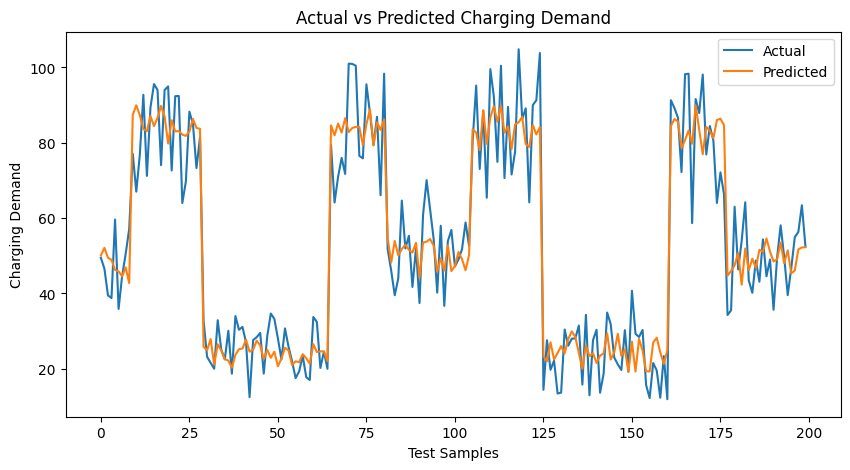

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    rf_predictions[:200],
    label="Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Charging Demand")
plt.title("Actual vs Predicted Charging Demand")
plt.legend()

plt.show()

In [16]:
joblib.dump(
    rf_demand,
    "/content/demand_model_rf.pkl"
)

joblib.dump(
    preprocessor,
    "/content/demand_preprocessor.pkl"
)

print("Model 1 saved.")

Model 1 saved.


In [17]:
import joblib
import os

os.makedirs("/content/models", exist_ok=True)

model_package = {
    "model": rf_demand,
    "preprocessor": preprocessor
}

joblib.dump(
    model_package,
    "/content/models/charging_demand_model.pkl"
)

print("Final Model 1 package saved.")

Final Model 1 package saved.


In [18]:
import json

test_input = {
    "station_id": "ST005",
    "location_type": "Urban",
    "vehicle_type": "Car",
    "battery_capacity_kWh": 60,
    "initial_soc": 35,
    "charging_power_kW": 22,
    "queue_length": 4,
    "electricity_price": 0.18,
    "renewable_energy_ratio": 0.42,
    "traffic_density": "High",
    "weather_condition": "Clear",
    "day_of_week": "Monday",
    "time_slot": "Peak",
    "hour": 18,
    "month": 2,
    "weekday_num": 0,
    "is_weekend": 0,
    "is_peak_hour": 1
}

os.makedirs("/content/test", exist_ok=True)

with open("/content/test/test_input.json", "w") as f:
    json.dump(test_input, f, indent=2)

print("Test input saved.")

Test input saved.


In [19]:
import pandas as pd

input_df = pd.DataFrame([test_input])

X_processed = preprocessor.transform(input_df)

prediction = rf_demand.predict(X_processed)[0]

print("Predicted charging demand:", prediction)

Predicted charging demand: 84.21325351640088


In [20]:
import json

sample_output = {
    "predicted_charging_demand": 84.21325351640088
}

with open("/content/sample_output.json", "w") as f:
    json.dump(sample_output, f, indent=2)

print("sample_output.json created")
print(sample_output)

sample_output.json created
{'predicted_charging_demand': 84.21325351640088}


In [21]:
import json

model_metadata = {
    "model_name": "EV Charging Demand Prediction",
    "model_version": "1.0.0",
    "model_type": "RandomForestRegressor",
    "target": "charging_demand",

    "features": [
        "station_id",
        "location_type",
        "vehicle_type",
        "battery_capacity_kWh",
        "initial_soc",
        "charging_power_kW",
        "queue_length",
        "electricity_price",
        "renewable_energy_ratio",
        "traffic_density",
        "weather_condition",
        "day_of_week",
        "time_slot",
        "hour",
        "month",
        "weekday_num",
        "is_weekend",
        "is_peak_hour"
    ],

    "preprocessing": {
        "method": "OneHotEncoder",
        "handle_unknown": "ignore"
    },

    "hyperparameters": {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 3,
        "random_state": 42
    },

    "performance": {
        "MAE": 7.698,
        "RMSE": 9.290,
        "R2": 0.887,
        "MAPE_percent": 18.60
    },

    "sample_prediction": 84.21325351640088
}

with open("/content/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("model_metadata.json created")

model_metadata.json created


In [22]:
requirements = """pandas
numpy
scikit-learn
matplotlib
xgboost
shap
joblib
"""

with open("/content/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [24]:
readme = """# Model 1 — EV Charging Demand Prediction

## Overview

This model predicts EV charging demand using a Random Forest Regressor.

## Model

- Algorithm: Random Forest Regressor
- Model version: 1.0.0
- Target: charging_demand

## Input Features

The model requires these 18 features:

- station_id
- location_type
- vehicle_type
- battery_capacity_kWh
- initial_soc
- charging_power_kW
- queue_length
- electricity_price
- renewable_energy_ratio
- traffic_density
- weather_condition
- day_of_week
- time_slot
- hour
- month
- weekday_num
- is_weekend
- is_peak_hour

## Model Performance

- MAE: 7.698
- RMSE: 9.290
- R2: 0.887
- MAPE: 18.60%

## How to Load the Model

Load the file models/charging_demand_model.pkl using joblib.

The file contains:
- trained Random Forest model
- preprocessing pipeline

## Prediction

Pass the 18 required features to the preprocessing pipeline and then to the Random Forest model.

The output is the predicted charging_demand.

## Repository Files

- models/charging_demand_model.pkl
- test/test_input.json
- sample_output.json
- model_metadata.json
- requirements.txt
- training/model_1_training.ipynb
"""

with open("/content/README.md", "w") as f:
    f.write(readme)

print("README.md created")

README.md created
